Accreted Milky Way Globular Clusters


Using data from the Harris Catalogue of Milky Way globular clusters and vandenBerg et al. (2013), use
stellar population (metallicities [Fe/H] and ages) and dynamical information to identify potentially
accreted globular clusters. Consider if there are some globular clusters that stand out in the age-metallicity relation or that do not rotate with the bulk of other globular clusters.
Consider what the above findings might mean for how the Milky Way formed and how many of its
globular clusters could be accreted and how many may have formed within the Milky Way. Consider
what further tests could be performed to delineate various possible formation scenarios.

In [2]:
# Import the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from mpdaf.obj import Image
from astropy.visualization import make_lupton_rgb
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, QTable
import plotly.express as px
from scipy.stats import linregress
#import PyQt5
#matplotlib qt


In [3]:
# Read in data files
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')
krause = pd.read_csv('Krause21.csv')
vandenberg = pd.read_csv('vandenBerg_table2.csv') 
progenitor = pd.read_csv('Progenitor.csv')

## Data Info

*Harris: CATALOG OF PARAMETERS FOR MILKY WAY GLOBULAR CLUSTERS*

**Harris Part I - Cluster identifications and positions**
- ['RA'], ['DEC'] Right ascention and Declination (epoch J2000)
- ['L'], ['B'] Galactic longitude and latitude (degrees)
- ['R_Sun'] Distance from Sun (kiloparsecs)
- ['R_gc'] Distance from Galactic center (kpc), assuming R_0=8.0 kpc
- ['X'], ['Y'], ['Z'] Galactic distance components X,Y,Z in kiloparsecs, in a Sun-centered coordinate system; X points toward Galactic center, Y in direction of Galactic rotation, Z toward North Galactic Pole

**Harris Part II - Metallicities, Integrated magnitudes, colors** *ignore for now*
- ['Fe/H'] Metallicity [Fe/H]
- ['wt'] Weight of mean metallicity; essentially the number of independent [Fe/H] measurements averaged together.
- ['E(B-V)'] Foreground reddening
- ['V_HB'] V magnitude level of the horizontal branch (or RR Lyraes)
- ['(m-M)V'] Apparent visual distance modulus
- ['V_t'] Integrated V magnitude of the cluster
- ['M_V,t'] Absolute visual magnitude (cluster luminosity),  M_V,t = V_t - (m-M)V
- ['U-B'], ['B-V'], ['V-R'], ['V-I'] Integrated color indices (uncorrected for reddening)
- ['spt] Spectral type of the integrated cluster light
- ['ellip'] Projected ellipticity of isophotes, e = 1-(b/a)

**Harris Part III - Radial velocities, velocity dispersions, structural parameters**
- ['v_r'] Heliocentric radial velocity (km/s)
- ['v_r_e'] Observational (internal) uncertainty in radial velocity
- ['v_LSR'] Radial velocity relative to Solar neighborhood LSR
- ['sig_v'] Central velocity dispersion sig_v (km/s)
- ['sig_v_e'] Observational (internal) uncertainty in velocity dispersion
- ['c'] King-model central concentration, c = log(r_t/r_c); a 'c' denotes a core-collapsed cluster
- ['r_c'] Core radius in arcmin
- ['r_h'] Half-light radius in arcmin
- ['mu_V'] Central surface brightness, V magnitudes per square arcsecond
- ['rho_0'] Central luminosity density, log_10(Solar luminosities per cubic parsec)
- ['lg_tc'] Core relaxation time t(r_c), in log_10(years)
- ['lg_th'] Median relaxation time t(r_h), in log_10(years)

**Krause**
- ['Mstar'] Stellar mass (Mstar) of the object
- ['rh'] Half-light radius (rh) of the object
- ['C5'] Compactness parameter (C5) of the object
- ['Age'] Age of the object (Gyr)
- ['FeH'] Metallicity [Fe/H]

**VandenBerg**
- ['FeH'] Metallicity [Fe/H]
- ['Age'] Age of the object (Gyr)
- ['Age_err'] Age uncertainty
- ['Method']
- ['Figs']
- ['Range']
- ['HBtype']
- ['R_G'] Distance from Galactic center (kpc)
- ['M_V'] Absolute visual magnitude
- ['v_e0'] Central escape velocity
- ['log_sigma_0'] Central logarithmic velocity dispersion

In [4]:
progenitor.head()

,Object,Progenitor
0,NGC104,IS
1,NGC288,AC
2,NGC362,AC
3,Whiting1,AC
4,NGC1261,AC


In [5]:
# Harris Part 1: make naming consistent
harris_p1.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p1['Object'] = harris_p1['Object'].astype(str) # make sure object column is string type
harris_p1['Object'] = harris_p1['Object'].str.replace(' ', '', regex=True) # remove spaces from object names
harris_p1.head()

,Object,Name,RA,DEC,L,B,R_Sun,R_gc,X,Y,Z
0,NGC104,47 Tuc,24:05.7,-72:04:52.6,305.89,-44.89,4.5,7.4,1.9,-2.6,-3.1
1,NGC288,NaN,52:45.2,-26:34:57.4,152.30,-89.38,8.9,12.0,-0.1,0.0,-8.9
2,NGC362,NaN,03:14.3,-70:50:55.6,301.53,-46.25,8.6,9.4,3.1,-5.1,-6.2
3,Whiting1,NaN,2:02:57,-03:15:10,161.22,-60.76,30.1,34.5,-13.9,4.7,-26.3
4,NGC1261,NaN,12:16.2,-55:12:58.4,270.54,-52.12,16.3,18.1,0.1,-10.0,-12.9


In [6]:
# IGNORE HARRIS P2 FOR NOW
harris_p2.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p2['Object'] = harris_p2['Object'].astype(str) # make sure object column is string type
harris_p2['Object'] = harris_p2['Object'].str.replace(' ', '', regex=True) # remove spaces from object names
harris_p2.head()

,Object,[Fe/H],wt,E(B-V),V_HB,(m-M)V,V_t,"M_V,t",U-B,B-V,V-R,V-I,spt,ellip
0,NGC104,-0.72,10,0.04,14.06,13.37,3.95,-9.42,0.37,0.88,0.53,1.14,G4,0.09
1,NGC288,-1.32,3,0.03,15.44,14.84,8.09,-6.75,0.08,0.65,0.45,0.94,,
2,NGC362,-1.26,5,0.05,15.44,14.83,6.4,-8.43,0.16,0.77,0.49,1.01,F9,0.01
3,Whiting1,-0.7,1,0.03,18.18,17.49,15.03,-2.46,,,,,,
4,NGC1261,-1.27,3,0.01,16.70,16.09,8.29,-7.8,0.13,0.72,0.45,0.93,F7,0.07


In [7]:
# Harris Part 3: make naming consistent
harris_p3.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p3['Object'] = harris_p3['Object'].astype(str) # make sure object column is string type
harris_p3['Object'] = harris_p3['Object'].str.replace(' ', '', regex=True) # remove spaces from object names
harris_p3.head()

,Object,v_r,v_r_e,v_LSR,sig_v,sig_v_e,c,r_c,r_h,mu_V,rho_0,lg_tc,lg_th
0,NGC104,-18.0,0.1,-26.7,11.0,0.3,2.07,0.36,3.17,14.38,4.88,7.84,9.55
1,NGC288,-45.4,0.2,-51.9,2.9,0.3,0.99,1.35,2.23,20.05,1.78,8.99,9.32
2,NGC362,223.5,0.5,214.0,6.4,0.3,1.76,0.18,0.82,14.80,4.74,7.76,8.93
3,Whiting1,-130.6,1.8,-138.1,NaN,NaN,0.55,0.25,0.22,NaN,NaN,NaN,7.93
4,NGC1261,68.2,4.6,54.9,NaN,NaN,1.16,0.35,0.68,17.73,2.99,8.59,9.12


In [8]:
# Krause: naming already consistent
krause.head() 

,Class,Object,AltName,Mstar,rh,C5,Age,FeH
0,GC,NGC104,47Tuc,6.46,7.10,0.92,12.80,-0.76
1,GC,NGC288,Melotte3,0.46,9.80,0.05,12.20,-1.32
2,GC,NGC362,Dunlop62,2.50,3.50,0.72,10.00,-1.26
3,GC,NGC1261,Caldwell87,3.41,5.50,0.62,10.24,-1.08
4,GC,NGC1851,Dunlop508,5.51,3.05,1.81,7.64,-1.13


In [9]:
# VandenBerg: make naming consistent
vandenberg.rename(columns={'#NGC': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
vandenberg['Object'] = vandenberg['Object'].astype(str) # make sure object column is string type
vandenberg['Object'] = 'NGC' + vandenberg['Object'] # add NGC to the start of each object
vandenberg.head()

,Object,Name,FeH,Age,Age_err,Method,Figs,Range,HBtype,R_G,M_V,v_e0,log_sigma_0
0,NGC104,47Tuc,-0.76,11.75,0.25,V,14,11.50–11.75,-0.99,7.4,-9.42,54.8,5.061
1,NGC288,XXXX,-1.32,11.50,0.38,H,24,NaN,0.98,12.0,-6.75,10.9,2.953
2,NGC362,XXXX,-1.30,10.75,0.25,V,13,10.75–11.00,-0.87,9.4,-8.43,44.4,4.938
3,NGC1261,XXXX,-1.27,10.75,0.25,V,13,10.75–11.25,-0.71,18.1,-7.80,23.6,3.913
4,NGC1851,XXXX,-1.18,11.00,0.25,V,13,10.75–11.25,-0.32,16.6,-8.33,47.6,5.136


In [10]:
# vandenberg data for NGC6121
vandenberg_feh = vandenberg[vandenberg['Object'] == 'NGC6121']['FeH'].values[0]
print(f"VandenBerg [Fe/H] for NGC6121: {vandenberg_feh}")
# krause data for NGC6121
krause_feh = krause[krause['Object'] == 'NGC6121']['FeH'].values[0]
print(f"Krause [Fe/H] for NGC6121: {krause_feh}")

VandenBerg [Fe/H] for NGC6121: -1.18
Krause [Fe/H] for NGC6121: -1.98


In [11]:
# merge data frames
merged_data = pd.merge(harris_p1, harris_p3, on='Object')
merged_data = pd.merge(merged_data, vandenberg, on='Object')
merged_data = pd.merge(merged_data, krause, on='Object')
merged_data = pd.merge(merged_data, progenitor, on='Object')
merged_data.columns

Index(['Object', 'Name_x', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'R_gc', 'X', 'Y',
       'Z', 'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h',
       'mu_V', 'rho_0', 'lg_tc', 'lg_th', 'Name_y', 'FeH_x', 'Age_x',
       'Age_err', 'Method', 'Figs', 'Range', 'HBtype', 'R_G', 'M_V', 'v_e0',
       'log_sigma_0', 'Class', 'AltName', 'Mstar', 'rh', 'C5', 'Age_y',
       'FeH_y', 'Progenitor'],
      dtype='object')

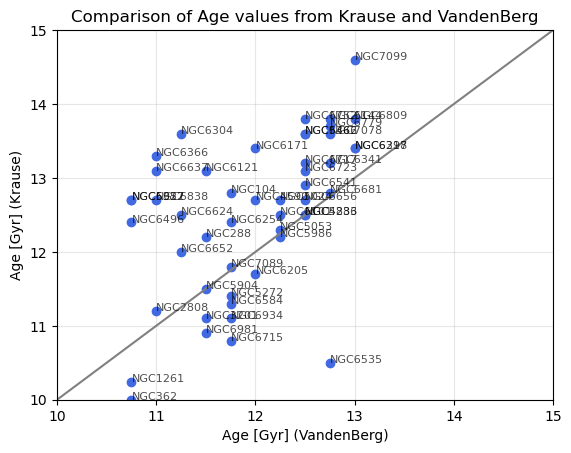

In [12]:
# plot the age values from krause vs vandenberg
plt.plot(merged_data['Age_x'], merged_data['Age_y'], marker='o', c='royalblue', linestyle='none')
plt.xlabel('Age [Gyr] (VandenBerg)')
plt.ylabel('Age [Gyr] (Krause)')
# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, (merged_data['Age_x'][i], merged_data['Age_y'][i]), fontsize=8, alpha=0.7)

plt.plot([10, 15], [10, 15], c='gray', linestyle='-') # 1:1 line
plt.xlim(10, 15)
plt.ylim(10, 15)
plt.grid(alpha=0.3)
plt.title('Comparison of Age values from Krause and VandenBerg')
plt.show()

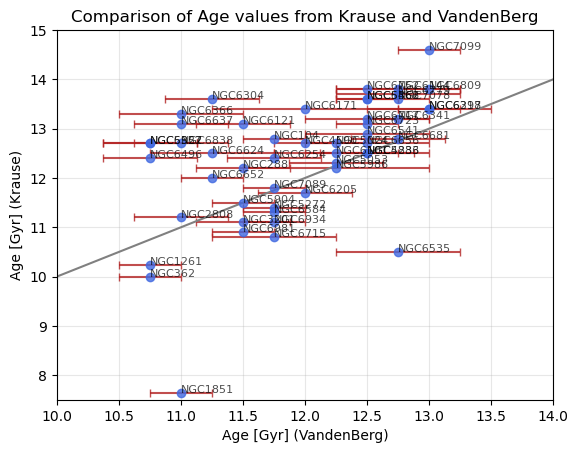

In [13]:
# plot the age values from krause vs vandenberg with error bars on VandenBerg ages
plt.errorbar(merged_data['Age_x'], merged_data['Age_y'], xerr=merged_data['Age_err'], marker='o', linestyle='none', color='royalblue', ecolor='firebrick', alpha=0.8, capsize=3, label='Globular Clusters')

# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, (merged_data['Age_x'][i], merged_data['Age_y'][i]), fontsize=8, alpha=0.7)

plt.plot([10, 15], [10, 15], c='gray', linestyle='-') # 1:1 line

plt.xlabel('Age [Gyr] (VandenBerg)')
plt.ylabel('Age [Gyr] (Krause)')
plt.xlim(10, 14)
plt.ylim(7.5, 15)
plt.grid(alpha=0.3)
plt.title('Comparison of Age values from Krause and VandenBerg')
plt.show()

# the two data sets dont agree that well, even with error bars theres quite a few globular clusters that aren't within range of each other.

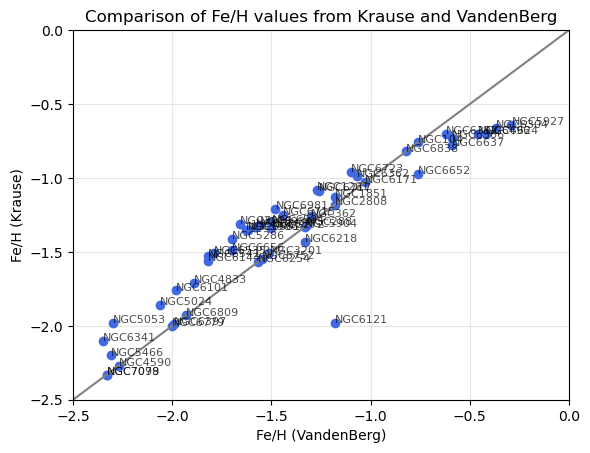

In [14]:
# plot the Fe/H values from krause vs vandenberg
plt.plot(merged_data['FeH_x'], merged_data['FeH_y'], marker='o', linestyle='none', c='royalblue')
plt.xlabel('Fe/H (VandenBerg)')
plt.ylabel('Fe/H (Krause)')
# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, (merged_data['FeH_x'][i], merged_data['FeH_y'][i]), fontsize=8, alpha=0.7)
plt.plot([-2.5, 0], [-2.5, 0], c='gray', linestyle='-') # 1:1 line
plt.xlim(-2.5, 0)
plt.ylim(-2.5, 0)
plt.grid(alpha=0.3)
plt.title('Comparison of Fe/H values from Krause and VandenBerg')
plt.show()

#there is slight discrepancy between the Fe/H values from the two sources but they generally agree

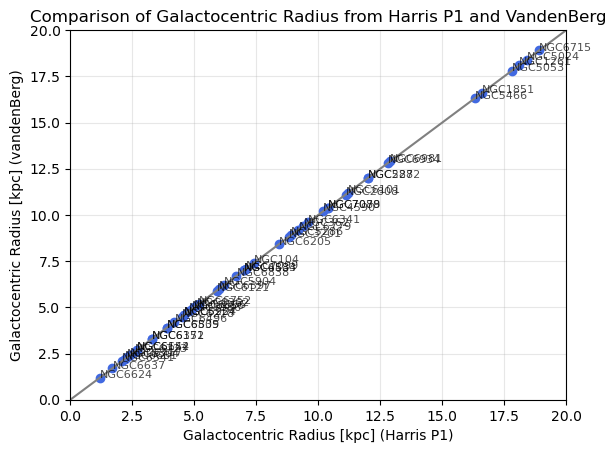

In [15]:
# plot the galactocentric radius values from harris p1 vs vandenberg
plt.plot(merged_data['R_gc'], merged_data['R_G'], marker='o', c='royalblue', linestyle='none')
plt.xlabel('Galactocentric Radius [kpc] (Harris P1)')
plt.ylabel('Galactocentric Radius [kpc] (vandenBerg)')
# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, (merged_data['R_gc'][i], merged_data['R_G'][i]), fontsize=8, alpha=0.7)
plt.plot([0, 20], [0, 20], c='gray', linestyle='-') # 1:1 line
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.grid(alpha=0.3)
plt.title('Comparison of Galactocentric Radius from Harris P1 and VandenBerg')
plt.show()

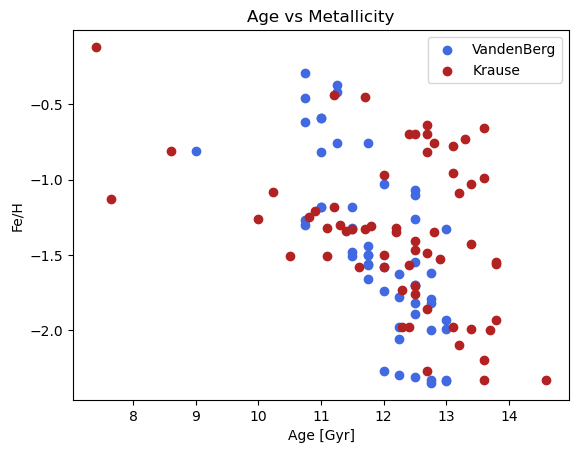

In [16]:
# Age-metallicity plot with data from VandenBerg and Krause
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='royalblue', label='VandenBerg')
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='firebrick', label='Krause')
plt.title('Age vs Metallicity')
plt.xlabel('Age [Gyr]')
plt.ylabel('Fe/H')
plt.legend()

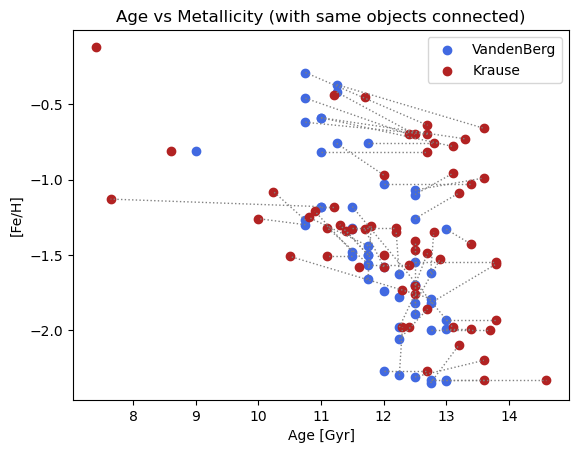

In [17]:
# Age-metallicity plot with data from VandenBerg and Krause with lines connecting matching objects
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='royalblue', label='VandenBerg')
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='firebrick', label='Krause')

# Connect matching objects
for object in set(vandenberg['Object']).intersection(krause['Object']): # find common objects
    v = vandenberg[vandenberg['Object'] == object].iloc[0] # get object row for vandenberg
    k = krause[krause['Object'] == object].iloc[0]  # get object row for krause
    plt.plot([v['Age'], k['Age']], [v['FeH'], k['FeH']],color='gray', linestyle=':', linewidth=1) # plot line between same objects

# labels
plt.title('Age vs Metallicity (with same objects connected)')
plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.legend()
plt.show()

# there is too much discrepancy here

In [18]:
# keep only the vandenberg (x) values for FeH, Age, and R_gc
merged_data['FeH'] = merged_data['FeH_x']
merged_data['Age'] = merged_data['Age_x']
merged_data['r_gc'] = merged_data['R_gc']

# drop the unnecessary duplicate columns
merged_data = merged_data.drop(columns=['FeH_x', 'FeH_y', 'Age_x', 'Age_y', 'R_gc', 'R_G'])

merged_data.columns

Index(['Object', 'Name_x', 'RA', 'DEC', 'L', 'B', 'R_Sun', 'X', 'Y', 'Z',
       'v_r', 'v_r_e', 'v_LSR', 'sig_v', 'sig_v_e', 'c', 'r_c', 'r_h', 'mu_V',
       'rho_0', 'lg_tc', 'lg_th', 'Name_y', 'Age_err', 'Method', 'Figs',
       'Range', 'HBtype', 'M_V', 'v_e0', 'log_sigma_0', 'Class', 'AltName',
       'Mstar', 'rh', 'C5', 'Progenitor', 'FeH', 'Age', 'r_gc'],
      dtype='object')

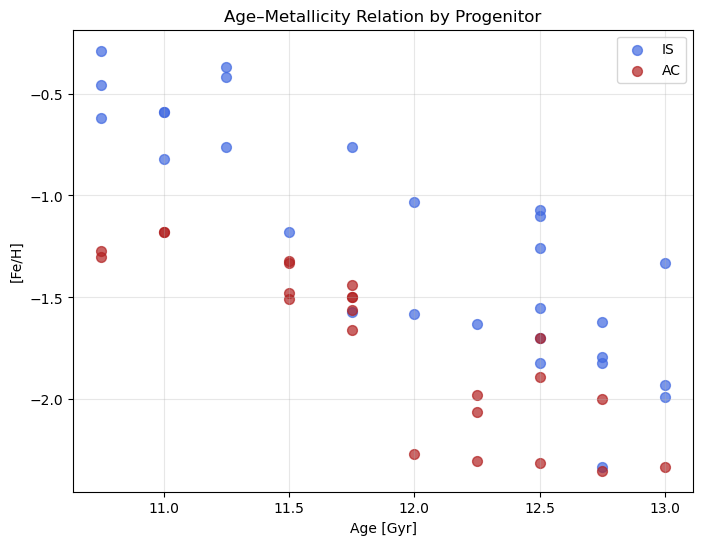

In [19]:
colors = {'IS':'royalblue', 'AC':'firebrick'}

plt.figure(figsize=(8,6))
for prog in ['IS','AC']:
    subset = merged_data[merged_data['Progenitor']==prog]
    plt.scatter(subset['Age'], subset['FeH'], 
                c=colors[prog], label=prog, s=50, alpha=0.7)

plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.title('Age–Metallicity Relation by Progenitor')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


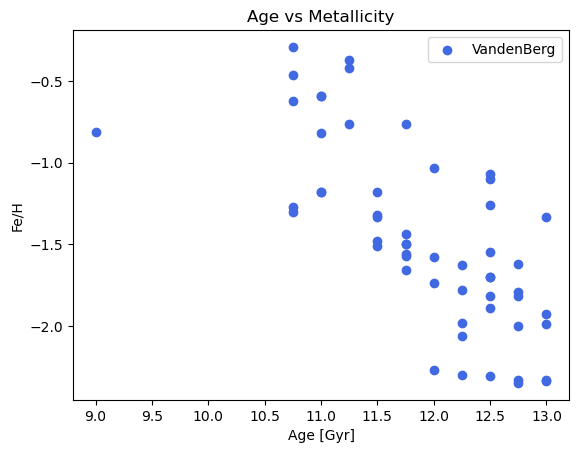

In [20]:
# Age-metallicity plot with data from VandenBerg and Krause
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='royalblue', label='VandenBerg')
plt.title('Age vs Metallicity')
plt.xlabel('Age [Gyr]')
plt.ylabel('Fe/H')
plt.legend()

# # label points with object names
# for i, txt in enumerate(vandenberg['Object']):
#     plt.annotate(txt, (vandenberg['Age'][i], vandenberg['FeH'][i]), fontsize=8, alpha=0.7)

In [21]:
print("Harris Part I:", len(harris_p1))
print("Harris Part III:", len(harris_p3))
print("Krause:", len(krause))
print("VandenBerg:", len(vandenberg))

Harris Part I: 157
Harris Part III: 157
Krause: 61
VandenBerg: 55


In [22]:
#objects each set has in common
set_harris = set(harris_p1['Object'])
set_harris3 = set(harris_p3['Object'])
set_krause = set(krause['Object'])
set_vandenberg = set(vandenberg['Object'])


print("Harris ∩ Harris:", len(set_harris & set_harris3))
print("Harris ∩ Krause:", len(set_harris & set_krause))
print("Harris ∩ VandenBerg:", len(set_harris & set_vandenberg))
print("Krause ∩ VandenBerg:", len(set_krause & set_vandenberg))
print("All three:", len(set_harris & set_krause & set_vandenberg))


Harris ∩ Harris: 157
Harris ∩ Krause: 59
Harris ∩ VandenBerg: 52
Krause ∩ VandenBerg: 51
All three: 51


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:3710: RuntimeWarning: invalid value encountered in divide
  return sin(y)/y


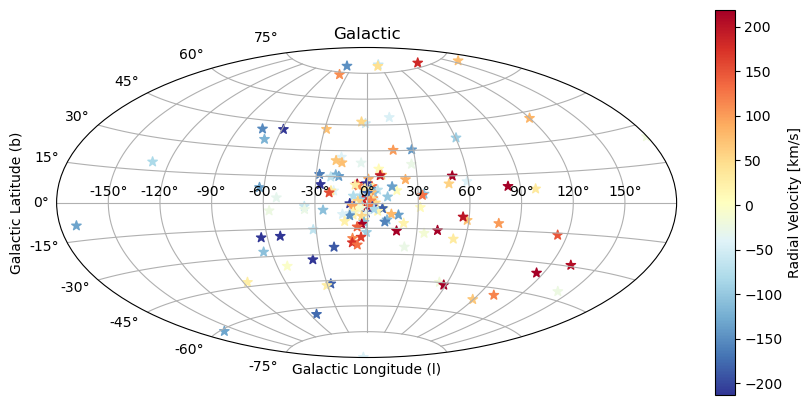

In [23]:
# plot sky distribution of GCs in Galactic coordinates

harris_p1['L'] = pd.to_numeric(harris_p1['L'], errors='coerce')
harris_p1['B'] = pd.to_numeric(harris_p1['B'], errors='coerce')
harris_p3['v_r'] = pd.to_numeric(harris_p3['v_r'], errors='coerce')

# Convert pandas into Angle objects
l = Angle(harris_p1['L'].to_numpy(), unit='deg')
b = Angle(harris_p1['B'].to_numpy(), unit='deg')
rv = harris_p3['v_r'].to_numpy()  # Radial Velocity

# Plot Galactic Coords
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')
sc = ax.scatter(-l.wrap_at('180d').radian, b.radian, s=50, c=rv, cmap='RdYlBu_r', vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95), marker='*')
plt.colorbar(sc, ax=ax, label='Radial Velocity [km/s]')
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("Galactic")

# # label points with object names
# for i, txt in enumerate(harris_p1['Object']):
#     plt.annotate(txt, xy=(-l.wrap_at('180d').radian[i], b.radian[i]), xytext=(3, 3), textcoords='offset points', fontsize=6, alpha=0.7,)

ax.grid()
plt.show()

# Figure displays GCs in Galactic coordinates with the centre of the Galaxy at the origin
# blue is blue shifted (moving towards us)
# red is red shifted (moving away from us)

# Potential Outliers:
# Ko2, NGC2419, Pal13, Eridanus, NGC6752, NGC3201, NGC6101, Djorg1, NGC6934, NGC7006, NGC6287, NGC6981, NGC7006, NGC4590, NGC5694, NGC4147, NGC5466, NGC2419, NGC5634, NGC6809, NGC288, Rup105, NGC5694, Pal12, IC1276, Pal15, NGC6254


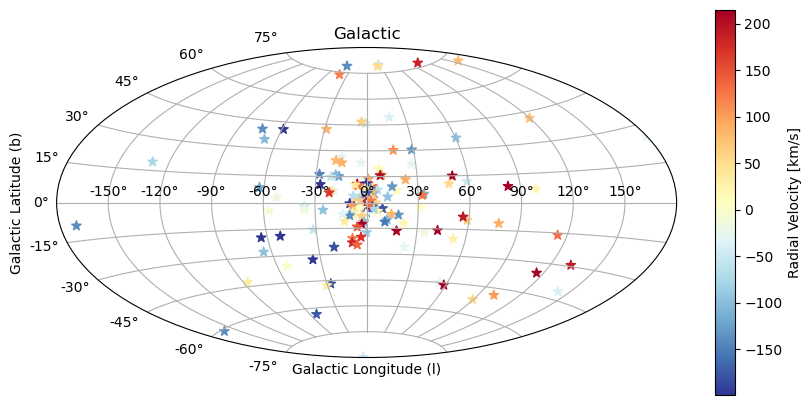

In [24]:
# plot sky distribution of GCs in Galactic coordinates

harris_p1['L'] = pd.to_numeric(harris_p1['L'], errors='coerce')
harris_p1['B'] = pd.to_numeric(harris_p1['B'], errors='coerce')
harris_p3['v_r'] = pd.to_numeric(harris_p3['v_r'], errors='coerce')

# Convert pandas into Angle objects
l = Angle(harris_p1['L'].to_numpy(), unit='deg')
b = Angle(harris_p1['B'].to_numpy(), unit='deg')
rv = harris_p3['v_LSR'].to_numpy()  # Radial Velocity

# Plot Galactic Coords
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')
sc = ax.scatter(-l.wrap_at('180d').radian, b.radian, s=50, c=rv, cmap='RdYlBu_r', vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95), marker='*')
plt.colorbar(sc, ax=ax, label='Radial Velocity [km/s]')
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("Galactic")

# # label points with object names
# for i, txt in enumerate(harris_p1['Object']):
#     plt.annotate(txt, xy=(-l.wrap_at('180d').radian[i], b.radian[i]), xytext=(3, 3), textcoords='offset points', fontsize=6, alpha=0.7,)

ax.grid()
plt.show()

In [28]:
harris_merged = pd.merge(harris_p1, harris_p3, on='Object')

# Map Progenitor to colors, fill missing with gray
colors = harris_merged['Progenitor'].map({'IS': 'royalblue', 'AC': 'firebrick'}).fillna('gray')

# Plot Galactic Coords
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')

sc = ax.scatter(-l.wrap_at('180d').radian, b.radian, s=50, c=colors, marker='*')

# Add legend manually (include gray for unknown)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='*', color='w', label='In-situ', markerfacecolor='royalblue', markersize=10),
    Line2D([0], [0], marker='*', color='w', label='Accreted', markerfacecolor='firebrick', markersize=10),
    Line2D([0], [0], marker='*', color='w', label='Unknown', markerfacecolor='gray', markersize=10)
]
ax.legend(handles=legend_elements, loc='lower left')

ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("Galactic")
ax.grid(True)
plt.show()



KeyError: 'Progenitor'

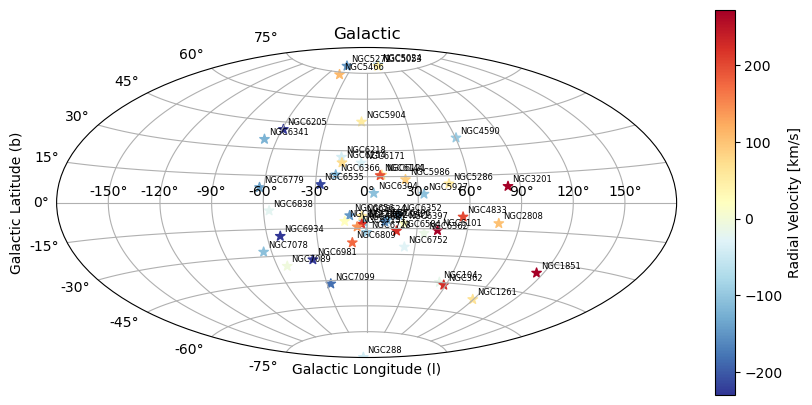

TypeError: can only concatenate str (not "list") to str

In [ ]:
# plot sky distribution of GCs in Galactic coordinates

merged_data['L'] = pd.to_numeric(merged_data['L'], errors='coerce')
merged_data['B'] = pd.to_numeric(merged_data['B'], errors='coerce')
merged_data['v_r'] = pd.to_numeric(merged_data['v_r'], errors='coerce')

# Convert pandas into Angle objects
l = Angle(merged_data['L'].to_numpy(), unit='deg')
b = Angle(merged_data['B'].to_numpy(), unit='deg')
rv = merged_data['v_r'].to_numpy()  # Radial Velocity

# Plot Galactic Coords
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')
sc = ax.scatter(-l.wrap_at('180d').radian, b.radian, s=50, c=rv, cmap='RdYlBu_r', vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95), marker='*')
plt.colorbar(sc, ax=ax, label='Radial Velocity [km/s]')
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("Galactic")

# label points with object names
for i, txt in enumerate(merged_data['Object']):
    plt.annotate(txt, xy=(-l.wrap_at('180d').radian[i], b.radian[i]), xytext=(3, 3), textcoords='offset points', fontsize=6)

ax.grid()
plt.show()

# Figure displays GCs in Galactic coordinates with the centre of the Galaxy at the origin
# blue is blue shifted (moving towards us)
# red is red shifted (moving away from us)

Outliers = 'NGC' + [288, 104, 6752, 5466, 6254, 7089, 4590, 5927, 6809, 5272, 5024, 5055, 6717, 6362]

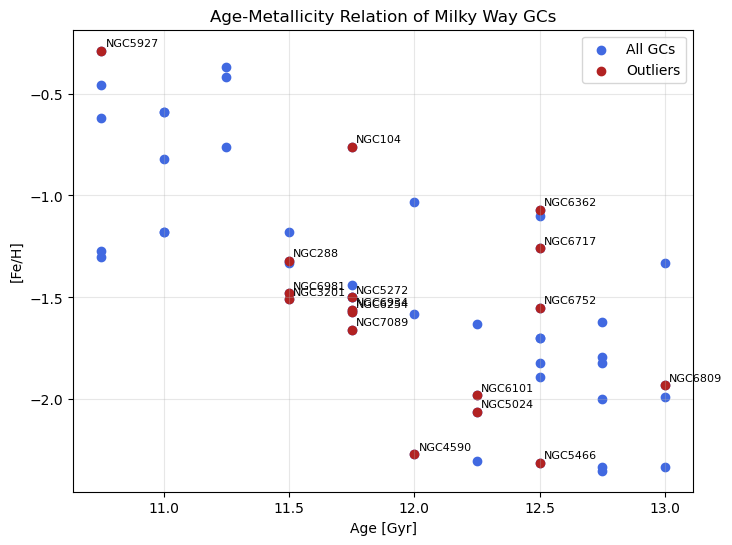

In [ ]:
import matplotlib.pyplot as plt

# Define outliers
Outliers = ['NGC288', 'NGC104', 'NGC6752', 'NGC5466', 'NGC6254', 
            'NGC7089', 'NGC4590', 'NGC5927', 'NGC6809', 'NGC5272', 
            'NGC5024', 'NGC5055', 'NGC6717', 'NGC6362', 'Ko2', 'NGC2419', 'Pal13', 'Eridanus',
            'NGC3201', 'NGC6101', 'Djorg1', 'NGC6934',
            'NGC7006', 'NGC6287', 'NGC6981']

# Basic Age-Metallicity plot
plt.figure(figsize=(8,6))
plt.scatter(merged_data['Age'], merged_data['FeH'], 
            color='royalblue', label='All GCs')

# Highlight outliers
mask_out = merged_data['Object'].isin(Outliers)
plt.scatter(merged_data.loc[mask_out, 'Age'], 
            merged_data.loc[mask_out, 'FeH'], 
            color='firebrick', label='Outliers')

# Optionally annotate
for i, obj in enumerate(merged_data.loc[mask_out, 'Object']):
    plt.annotate(obj, (merged_data.loc[mask_out, 'Age'].iloc[i], 
                       merged_data.loc[mask_out, 'FeH'].iloc[i]),
                 fontsize=8, xytext=(3,3), textcoords='offset points')

plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.title('Age-Metallicity Relation of Milky Way GCs')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from astropy.coordinates import Angle

# # Clean data
# mask = (~harris_p1['L'].isna()) & (~harris_p3['v_r'].isna())
# l = Angle(harris_p1.loc[mask, 'L'].to_numpy(), unit='deg')
# rv = harris_p3.loc[mask, 'v_r'].to_numpy()

# # Wrap longitude to [-180, 180]
# l_rad = l.wrap_at('180d').radian
# l_deg = np.degrees(l_rad)

# from scipy.optimize import curve_fit

# def rotation_func(l, V_amp, l0, V_sys):
#     return V_amp * np.sin(np.radians(l) - np.radians(l0)) + V_sys

# p0 = [100, 90, 0]  # initial guesses
# params, cov = curve_fit(rotation_func, l_deg, rv, p0=p0)
# V_amp, l0, V_sys = params
# print(f"Rotation fit parameters:\nAmplitude = {V_amp:.1f} km/s\nPhase (l0) = {l0:.1f}°\nSystemic = {V_sys:.1f} km/s")

# plt.figure(figsize=(9,5))
# plt.scatter(l_deg, rv, c='royalblue', s=40, alpha=0.7, label='Data')

# l_fit = np.linspace(-180, 180, 500)
# rv_fit = rotation_func(l_fit, *params)
# plt.plot(l_fit, rv_fit, 'r-', lw=2, label='Fitted Rotation')


# plt.xlabel("Galactic Longitude [deg]")
# plt.ylabel("Radial Velocity [km/s]")
# plt.title("Globular Cluster Velocities vs Galactic Longitude")
# plt.legend()
# plt.grid(alpha=0.3)
# plt.show()

# residuals = rv - rotation_func(l_deg, *params)

# # Threshold for outliers (e.g. >2σ from trend)
# sigma = np.nanstd(residuals)
# outlier_mask = np.abs(residuals) > 2 * sigma

# outliers = harris_p1.loc[mask].loc[outlier_mask, 'Object']
# print("Clusters moving against rotation (>2σ from trend):")
# print(outliers.tolist())

# fig = plt.figure(figsize=(10,6))
# ax = fig.add_subplot(111, projection='aitoff')

# # All clusters
# ax.scatter(-l_rad, np.radians(harris_p1.loc[mask, 'B']), c=rv, cmap='RdYlBu_r',
#            vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95),
#            s=40, alpha=0.8)

# # Outliers highlighted
# ax.scatter(-l_rad[outlier_mask], np.radians(harris_p1.loc[mask, 'B'])[outlier_mask],
#            s=80, facecolor='none', edgecolor='black', lw=1.5, label='Kinematic Outliers')

# ax.legend()
# ax.set_title("Globular Clusters in Galactic Coordinates (Velocity Outliers)")
# ax.grid()
# plt.show()

# # Outlier Clusters (>2σ from fitted trend): ['NGC3201' 'NGC6101' 'NGC6287' 'Djorg1' 'NGC6934' 'NGC6981' 'NGC7006']


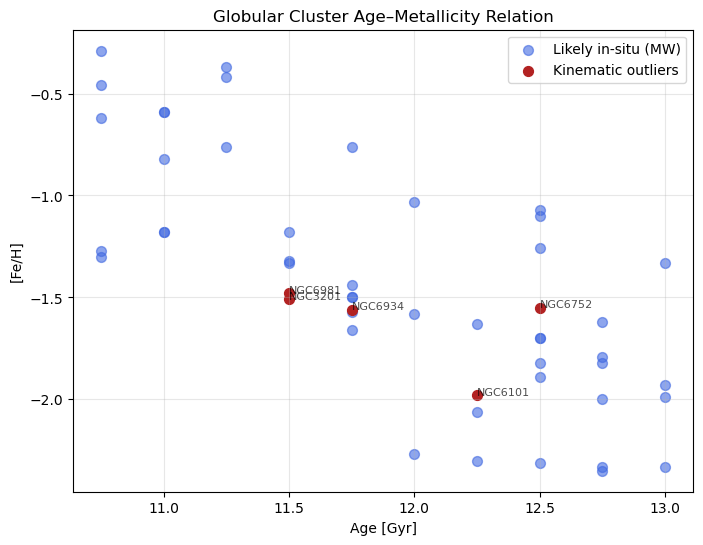

In [ ]:

# List of kinematic outliers
outliers = ['Ko2', 'NGC2419', 'Pal13', 'Eridanus', 'NGC6752',
            'NGC3201', 'NGC6101', 'Djorg1', 'NGC6934',
            'NGC7006', 'NGC6287', 'NGC6981', 'NGC7006']

# Mark clusters as outliers
merged_data['Outlier'] = merged_data['Object'].isin(outliers)

# Plot Age–Metallicity Relation (Age on x-axis)
plt.figure(figsize=(8,6))
plt.scatter(merged_data[~merged_data['Outlier']]['Age'], merged_data[~merged_data['Outlier']]['FeH'], color='royalblue',s=50, alpha=0.6, label='Likely in-situ (MW)')
plt.scatter(merged_data[merged_data['Outlier']]['Age'], merged_data[merged_data['Outlier']]['FeH'], c='firebrick', s=50, label='Kinematic outliers')

# Annotate outlier names
for i, row in merged_data[merged_data['Outlier']].iterrows():
    plt.annotate(row['Object'], (row['Age'], row['FeH']), fontsize=8, alpha=0.7)

plt.xlabel('Age [Gyr]')
plt.ylabel('[Fe/H]')
plt.title('Globular Cluster Age–Metallicity Relation')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:3710: RuntimeWarning: invalid value encountered in divide
  return sin(y)/y


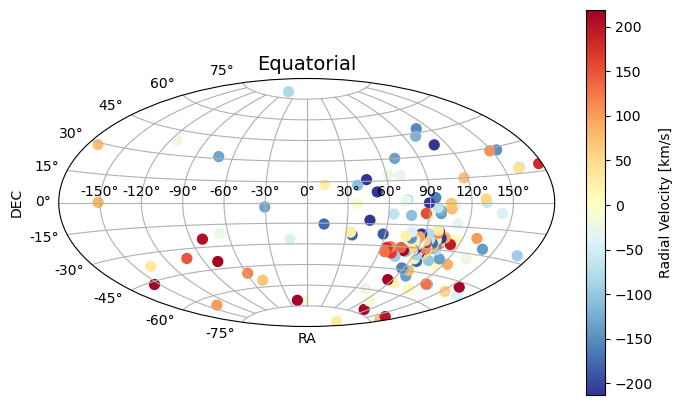

In [ ]:
# plot sky distribution of GCs in Equatorial coordinates

galactic_coords = SkyCoord(l=l, b=b, frame='galactic') # Convert to Equatorial coordinates
equatorial_coords = galactic_coords.icrs 

ra_rad = np.radians(equatorial_coords.ra.wrap_at(180*u.degree).value)  # Wrap RA with 0 in centre and convert to radians
dec_rad = np.radians(equatorial_coords.dec.value)  # Convert Dec to radians

# plot with Aitoff projection
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': 'aitoff'})

# Scatter plot
cs = ax.scatter(-ra_rad, dec_rad, s=50, marker='o', c=rv, cmap='RdYlBu_r', vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95))
plt.colorbar(cs, ax=ax, label='Radial Velocity [km/s]')
ax.set_xlabel("RA")
ax.set_ylabel("DEC")
ax.grid()
ax.set_title('Equatorial', fontsize=14)
plt.show()

Try to find which GCs dont rotate withthe bulk and see how that correlates with the other data plots.
- HR diagram??
- Number of globular clusters vs distance from galactic centre
- 
- HB tye vs metallicity??

dynamics
- energy vs angular momentum
- distance from galactiv centre vs radial velocity
- distance from galactiv centre vs Fe/H
- radial velocity vs Fe/H

In [ ]:
merged_data['L'] = pd.to_numeric(merged_data['L'], errors='coerce')
merged_data['B'] = pd.to_numeric(merged_data['B'], errors='coerce')
l = Angle(merged_data['L'].to_numpy(), unit='deg')
b = Angle(merged_data['B'].to_numpy(), unit='deg')
merged_data['FeH'] = pd.to_numeric(merged_data['FeH'], errors='coerce')
merged_data['r_gc'] = pd.to_numeric(merged_data['r_gc'], errors='coerce')
r_gc = np.array(merged_data['r_gc'])  # Galactocentric Radius

def scatter3Dmaker(data, color_label, title, color_scale):
    
    # Convert galactic coordinates to Cartesian
    x = r_gc * np.cos(b) * np.cos(l)
    y = r_gc * np.cos(b) * np.sin(l)
    z = r_gc * np.sin(b)

    # DataFrame for plotly
    stars_df = pd.DataFrame({'x': x, 'y': y, 'z': z})   

    fig = px.scatter_3d(stars_df, x='x', y='y', z='z', color=data,
                        title=title, color_continuous_scale=color_scale)

    fig.update_traces(marker=dict(size=5))
    fig.update_layout(coloraxis_colorbar=dict(title=dict(text=color_label)))

    fig.show()

In [ ]:
# 3d plot of metallicity
scatter3Dmaker(merged_data['FeH'], 'Metallicity [Fe/H]', 'Metallicity of Stars', 'inferno')

In [ ]:
import plotly.express as px

# Convert galactic coordinates to Cartesian
x = merged_data['r_gc'] * np.cos(np.radians(merged_data['B'])) * np.cos(np.radians(merged_data['L']))
y = merged_data['r_gc'] * np.cos(np.radians(merged_data['B'])) * np.sin(np.radians(merged_data['L']))
z = merged_data['r_gc'] * np.sin(np.radians(merged_data['B']))

merged_data['x'] = x
merged_data['y'] = y
merged_data['z'] = z

fig = px.scatter_3d(merged_data, x='x', y='y', z='z',
                    color='Progenitor',
                    color_discrete_map={'IS':'royalblue','AC':'firebrick'},
                    symbol='Progenitor',
                    title='3D Distribution of Milky Way GCs by Progenitor',
                    labels={'color':'Progenitor'})

fig.update_traces(marker=dict(size=5))
fig.show()


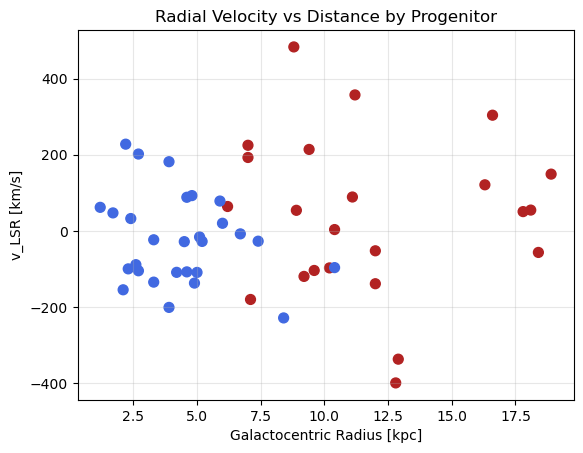

In [ ]:
plt.scatter(merged_data['r_gc'], merged_data['v_LSR'], 
            c=merged_data['Progenitor'].map(colors), s=50)
plt.xlabel('Galactocentric Radius [kpc]')
plt.ylabel('v_LSR [km/s]')
plt.title('Radial Velocity vs Distance by Progenitor')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
mask = merged_data[['Y','v_r']].notna().all(axis=1)
slope, intercept, r, p, stderr = linregress(merged_data.loc[mask, 'Y'], merged_data.loc[mask, 'v_r'])
v_expected = intercept + slope * merged_data['Y']
residuals = merged_data['v_r'] - v_expected

print("Slope:", slope)
print("Correlation coefficient (r):", r)
print("Residual std dev:", residuals.std())

Slope: -21.359511620737923
Correlation coefficient (r): -0.6022587433948302
Residual std dev: 136.60457398330826


In [ ]:
# Identify outliers based on residuals
threshold = 1.15 * residuals.std()
outliers = merged_data[abs(residuals) > threshold]

print("Number of outliers:", len(outliers))
print(outliers[['Object', 'Y', 'v_r', 'FeH']])

Number of outliers: 12
     Object    Y    v_r   FeH
6   NGC3201 -4.8  494.0 -1.51
7   NGC4590 -7.2  -94.7 -2.27
13  NGC5466  3.0  110.7 -2.31
15  NGC5927 -4.2 -107.5 -0.29
19  NGC6144 -1.2  193.8 -1.82
26  NGC6352 -1.8 -137.0 -0.62
32  NGC6541 -1.4 -158.7 -1.82
38  NGC6681  0.4  220.3 -1.62
39  NGC6715  2.5  141.3 -1.44
44  NGC6809  0.8  174.7 -1.93
47  NGC6981  8.3 -345.0 -1.48
49  NGC7089  7.5   -5.3 -1.66


NameError: name 'v_expected' is not defined

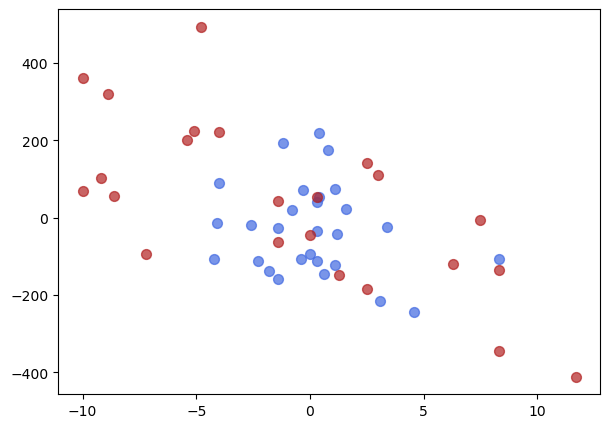

In [26]:
#plot progenitor instead of outliers
plt.figure(figsize=(7,5))
for prog in ['IS','AC']:
    subset = merged_data[merged_data['Progenitor']==prog]
    plt.scatter(subset['Y'], subset['v_r'], 
                c=colors[prog], label=prog, s=50, alpha=0.7)    
plt.plot(merged_data['Y'], v_expected, color='black', lw=1.5, label='Best-fit rotation trend')
plt.axhline(0, color='gray', ls=':')
plt.axvline(0, color='gray', ls=':')
plt.xlabel('Y (kpc)')

# plot rotation and outliers
plt.figure(figsize=(7,5))
plt.scatter(merged_data['Y'], merged_data['v_r'], color='royalblue', label='All clusters')
plt.scatter(outliers['Y'], outliers['v_r'], color='firebrick', label='Outliers')
plt.plot(merged_data['Y'], v_expected, color='black', lw=1.5, label='Best-fit rotation trend')
plt.axhline(0, color='gray', ls=':')
plt.axvline(0, color='gray', ls=':')
plt.xlabel('Y (kpc)')
plt.ylabel('Heliocentric v_r (km/s)')
plt.title('Rotation and Outliers')
plt.legend()
plt.show()


Text(0, 0.5, 'Fe/H')

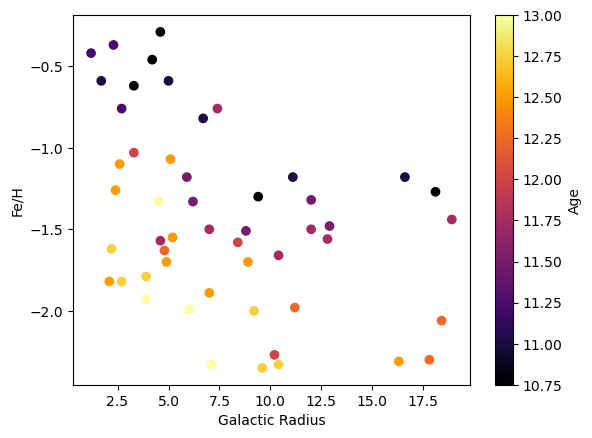

In [ ]:
# Plot metallicity along Galactic Radius with points colored by Age

plt.scatter(r_gc, merged_data['FeH'], c=merged_data['Age'], cmap='inferno')
plt.colorbar(label='Age')
plt.xlabel('Galactic Radius')
plt.ylabel('Fe/H')
plt.title('Metallicity vs Galactic Radius Colored by Age')

To do: 
- use only vandenberg for age and metallicity data (no krause) and see if there are any differences. 
- find more ways of determining accreted GC's
- analysis of plots
- write up what we would expect from the properties of accreted GC's

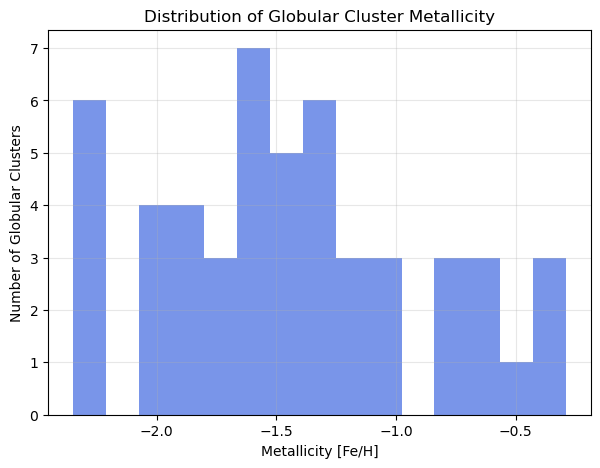

In [ ]:
#histagram of metallicity and number of globular clusters
plt.figure(figsize=(7,5))
plt.hist(merged_data['FeH'], bins=15, color='royalblue', alpha=0.7)
plt.xlabel('Metallicity [Fe/H]')
plt.ylabel('Number of Globular Clusters')
plt.title('Distribution of Globular Cluster Metallicity')
plt.grid(alpha=0.3)
plt.show()

# bimodality should be present in in-situ globular clusters


Text(0.5, 1.0, 'Spatial Distribution of Globular Clusters')

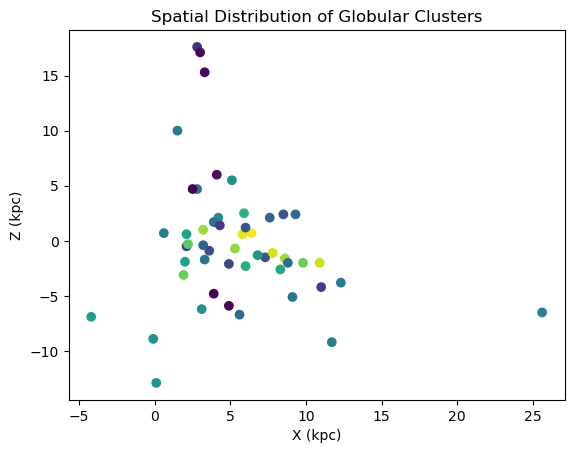

In [ ]:
plt.scatter(merged_data['X'], merged_data['Z'], c=merged_data['FeH'], cmap='viridis')
plt.xlabel('X (kpc)'); plt.ylabel('Z (kpc)')
plt.title('Spatial Distribution of Globular Clusters')


In [ ]:
merged_harris = pd.merge(harris_p1, harris_p3, on='Object')

# velocity vs alactic longitude plot wrapped at 180 degrees

plt.figure(figsize=(8,5))
# Wrap L at 180 degrees for better visualization
L_wrapped = merged_harris['L'].apply(lambda x: x-360 if x > 180 else x)
plt.scatter(L_wrapped, merged_harris['v_r'], color='royalblue', marker='o', label='Globular Clusters')
plt.xlabel('Galactic Longitude L (degrees)')
plt.ylabel('Radial Velocity v_r (km/s)')
plt.title('Radial Velocity vs Galactic Longitude L (wrapped at 180 degrees)') 
# add a sinusoidal fit
# Define sinusoidal function
def v_sin(L_deg, v0, A, L0):
    L = np.radians(L_deg)
    return v0 + A * np.sin(L - np.radians(L0))      

#remove nans or infs
mask = np.isfinite(merged_harris["L"]) & np.isfinite(merged_harris["v_r"])
merged_harris = merged_harris[mask]

#plot sinusoidal fit
# Initial guess for parameters: v0=0, A=200, L0=0
p0 = [0, 200, 0]
popt, pcov = curve_fit(v_sin, merged_harris['L'], merged_harris['v_r'], p0=p0, maxfev=10000)
L_fit = np.linspace(-180, 180, 400)
v_fit = v_sin(L_fit, *popt)
plt.plot(L_fit, v_fit, color='orange', linewidth=2, label='Sinusoidal Fit')
plt.legend()
plt.show()